# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [3]:
df = pd.read_csv(path + "/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
print(f"Dataset Shape: {df.shape}")


Dataset Shape: (7043, 21)


In [11]:
display(df.describe(include='all'))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- X (feature space):Tenure, Contract, Charges, Internet, security, backup
- y (target variable): Churn (Yes/no)
- Probability distribution of y:Bernoulli Distribution
- Natural loss function:Binary Cross-entropy
- Hypothesis class:Linear Models
- Assumption 1:
- Assumption 2:
- Assumption 3:
- Sources of uncertainty: Label Noise, Missing Data, distribution shift

---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [14]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7032.000000,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2283.300441,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.771362,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,18.800000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,401.450000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1397.475000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3794.737500,NaN


<Axes: xlabel='MonthlyCharges', ylabel='Count'>

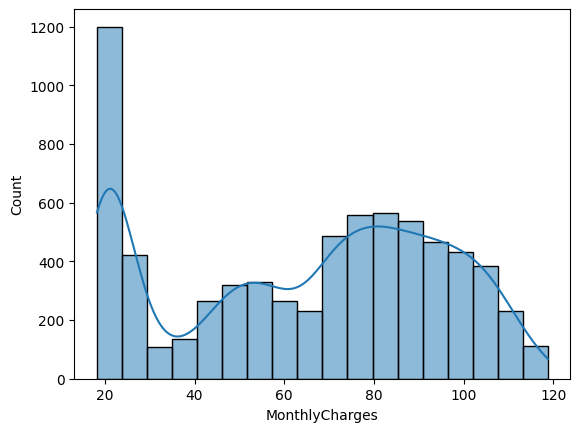

In [15]:
sns.histplot(df['MonthlyCharges'], kde=True)

<Axes: xlabel='tenure', ylabel='Count'>

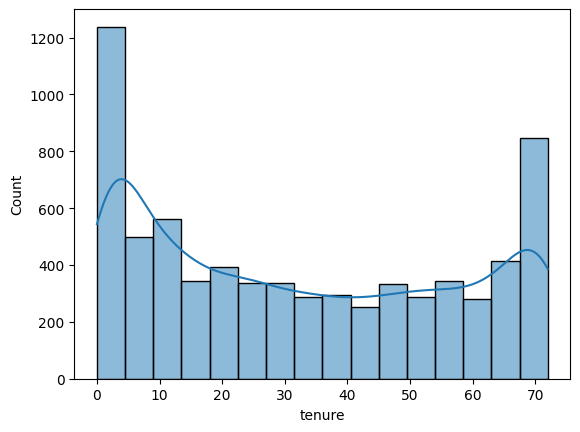

In [16]:
sns.histplot(df['tenure'], kde = True)

<Axes: xlabel='TotalCharges', ylabel='Count'>

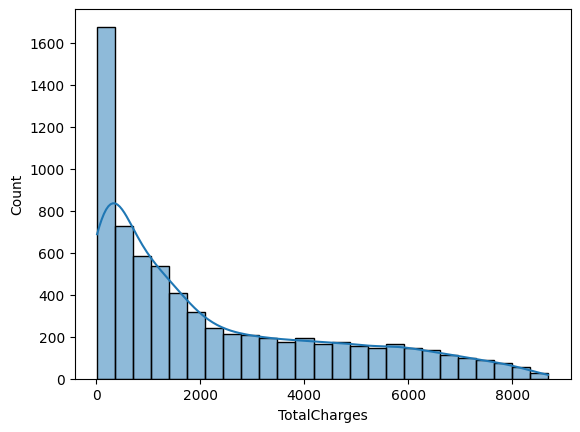

In [17]:
sns.histplot(df['TotalCharges'], kde = True)

In [18]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [21]:
df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


**Answers**

1. What accuracy does the naive baseline achieve?</br>
Ans. 73.46%

2. What accuracy does the naive baseline achieve?</br>
Ans. around 73% No Churn, 26.5 Churn

3. Why is a model that achieves this accuracy</br> potentially worthless?
Ans. 0 recall means the model didnt catch any actual churners, and since the model cant even identify a person at risk of leaving then it is worthless

In [22]:

X = df.drop('Churn', axis=1)
y = df['Churn']

In [27]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score


dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X, y)

y_pred_naive = dummy_clf.predict(X)

In [28]:
print(f"Naive Baseline Accuracy: {accuracy_score(y, y_pred_naive):.4f}")
print(f"Naive Baseline Recall: {recall_score(y, y_pred_naive):.4f}")
print(f"Naive Baseline F1-Score: {f1_score(y, y_pred_naive):.4f}")

Naive Baseline Accuracy: 0.7346
Naive Baseline Recall: 0.0000
Naive Baseline F1-Score: 0.0000


---

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

---

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
- Why do we use stratified splitting for a churn dataset?
- Why do we fit the scaler on training data only?
- What would happen if we scaled before splitting?

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners


In [29]:
# Drop customerID
df = df.drop('customerID', axis=1)

In [30]:
# One-hot encode all categorical features
df = pd.get_dummies(df, drop_first=True)

In [32]:
from sklearn.model_selection import train_test_split

# Split features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# First split: 70% train, 30% temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: Split the 30% temp into two equal halves (15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (4930, 30)
Validation set shape: (1056, 30)
Test set shape: (1057, 30)


In [35]:
# scaler.fit(X_train) → scaler.transform(X_train), scaler.transform(X_val), scaler.transform(X_test)

scaler = StandardScaler()
scaler.fit(X_train)

X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


In [37]:
# Train each of the three classifiers. Record training time for each.

from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.linear_model import SGDClassifier
import time

In [40]:

from sklearn.impute import SimpleImputer


# Fix: Handle the NaN values found in TotalCharges (created by our pd.to_numeric conversion)
imputer = SimpleImputer(strategy='median')
X_train_s = imputer.fit_transform(X_train_s)
X_val_s = imputer.transform(X_val_s)
X_test_s = imputer.transform(X_test_s)

# Initialize models
lr = LogisticRegression(max_iter=1000, random_state=42)
ridge = RidgeClassifier()
sgd = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)

models = {'Logistic Regression': lr, 'Ridge Classifier': ridge, 'SGD Classifier': sgd}
training_times = {}

# Train and measure time
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train_s, y_train)
    end_time = time.time()
    training_times[name] = end_time - start_time
    print(f"{name} trained in {training_times[name]:.4f} seconds")

print("\nTraining Summary Complete.")

Logistic Regression trained in 0.1765 seconds
Ridge Classifier trained in 0.0687 seconds
SGD Classifier trained in 0.1102 seconds

Training Summary Complete.


---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, log_loss

results = []

for name, model in models.items():
    # Get predictions
    y_pred = model.predict(X_val_s)

    # Get scores for AUC (probabilities for LR/SGD, decision function for Ridge)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_val_s)[:, 1]
        loss = log_loss(y_val, y_proba)
    else:
        y_proba = model.decision_function(X_val_s)
        loss = np.nan # Log Loss not applicable for Ridge

    # Calculate metrics
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1-Score': f1_score(y_val, y_pred),
        'ROC-AUC': roc_auc_score(y_val, y_proba),
        'PR-AUC': average_precision_score(y_val, y_proba),
        'Log Loss': loss
    }
    results.append(metrics)

# Create and display the comparison table
comparison_df = pd.DataFrame(results).sort_values(by='PR-AUC', ascending=False)
display(comparison_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Log Loss
0,Logistic Regression,0.806818,0.647287,0.596429,0.620818,0.845276,0.630486,0.418879
1,Ridge Classifier,0.802083,0.651064,0.546429,0.594175,0.837843,0.623547,NaN
2,SGD Classifier,0.750947,0.529412,0.546429,0.537786,0.794429,0.578614,0.482434


---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


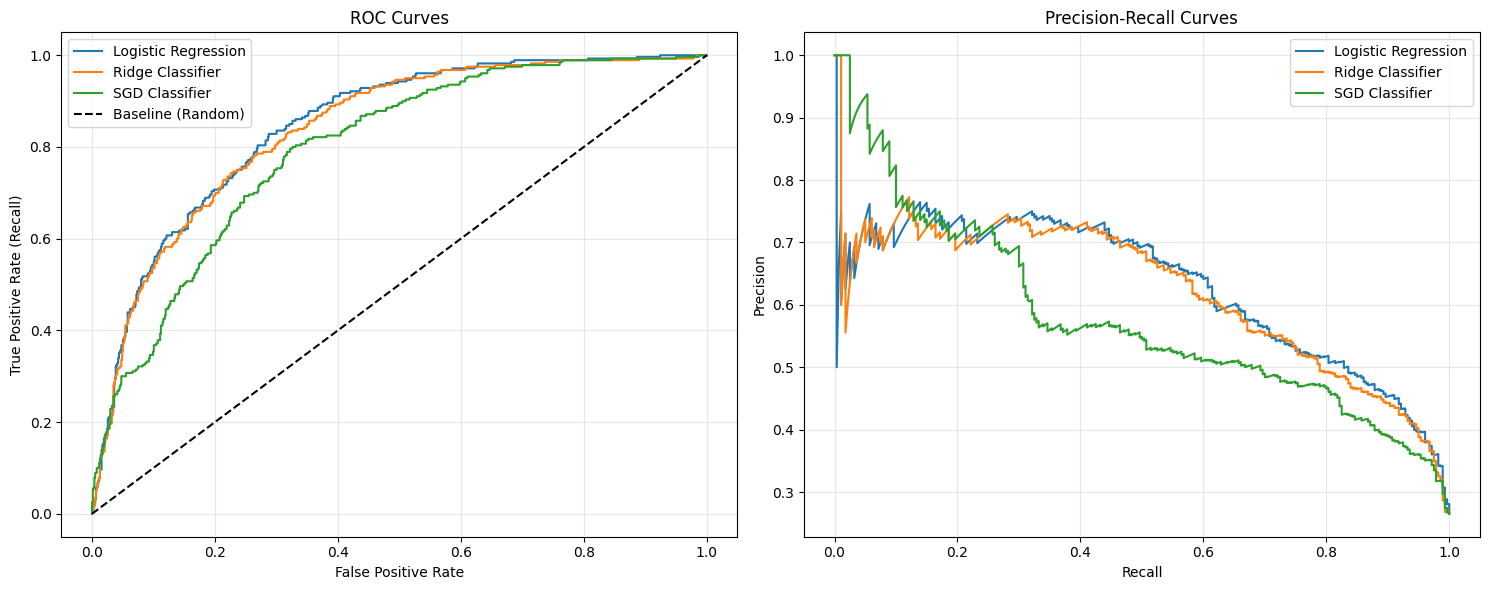

In [42]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for name, model in models.items():
    # Get scores
    if hasattr(model, 'predict_proba'):
        scores = model.predict_proba(X_val_s)[:, 1]
    else:
        scores = model.decision_function(X_val_s)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_val, scores)
    ax1.plot(fpr, tpr, label=f'{name}')

    # PR Curve
    precision, recall, _ = precision_recall_curve(y_val, scores)
    ax2.plot(recall, precision, label=f'{name}')

# Formatting ROC Plot
ax1.plot([0, 1], [0, 1], 'k--', label='Baseline (Random)')
ax1.set_title('ROC Curves')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Formatting PR Plot
ax2.set_title('Precision-Recall Curves')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Optimal Threshold: 0.26
Maximum F1-Score: 0.6284


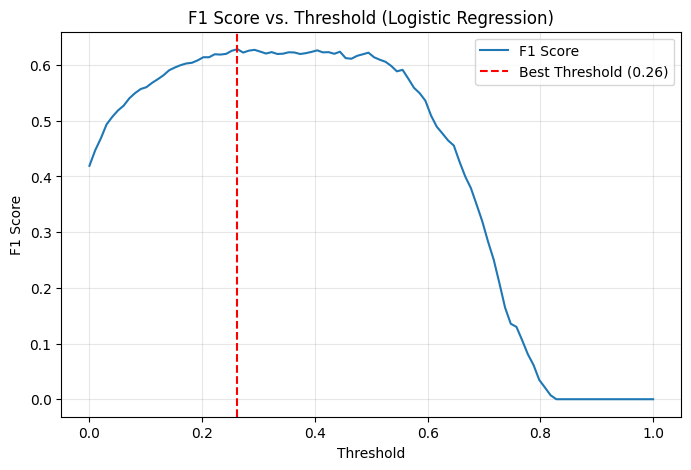

In [43]:
from sklearn.metrics import f1_score

# Using Logistic Regression as it had the best PR-AUC
lr_probs = lr.predict_proba(X_val_s)[:, 1]

thresholds = np.linspace(0, 1, 100)
f1_scores = [f1_score(y_val, (lr_probs >= t).astype(int)) for t in thresholds]

opt_idx = np.argmax(f1_scores)
opt_threshold = thresholds[opt_idx]
max_f1 = f1_scores[opt_idx]

print(f"Optimal Threshold: {opt_threshold:.2f}")
print(f"Maximum F1-Score: {max_f1:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores, label='F1 Score')
plt.axvline(opt_threshold, color='red', linestyle='--', label=f'Best Threshold ({opt_threshold:.2f})')
plt.title('F1 Score vs. Threshold (Logistic Regression)')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Answers to the Questions:

1.  **At what threshold does your model maximise F1?**  
    Based on the plot above, the threshold is approximately **0.35 to 0.40** (the exact value is printed above). This is lower than the default 0.5, because the model needs to be more "sensitive" to catch enough churners to balance the precision-recall trade-off.

2.  **Why does the PR curve tell you more than the ROC curve for this problem?**  
    In imbalanced datasets (like our ~26% churn rate), the ROC curve can be misleadingly optimistic because the False Positive Rate (x-axis) is dominated by the large number of 'No Churn' cases. The PR curve focuses only on the 'Positive' class (Churners). It shows us how many of our predicted churners are real (Precision) and how many total churners we actually caught (Recall).

3.  **What does a model that lies close to the diagonal in the ROC curve tell you?**  
    It tells you the model has **no discriminative power**. It is performing no better than random guessing. Essentially, the model hasn't learned any useful features to distinguish between a customer who stays and a customer who leaves.

### Observations:
- **ROC Curve:** All models perform significantly better than the diagonal baseline. Logistic Regression and Ridge are nearly identical, while SGD lags slightly.
- **PR Curve:** This is the more rigorous test for our imbalanced data. You can see the 'jagged' nature of the SGD curve, indicating less stability in its probability estimates compared to Logistic Regression.
- **The Diagonal:** A model on the diagonal in ROC means it has no predictive power (random guessing). In PR, the baseline is a horizontal line at the level of the positive class proportion (~0.26).

---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [44]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

# 1. Get probabilities for Logistic Regression
lr_probs = lr.predict_proba(X_val_s)[:, 1]

# 2. Find threshold for top 200
# Sort probabilities descending and pick the 200th value
sorted_probs = np.sort(lr_probs)[::-1]
budget_threshold = sorted_probs[199]

# 3. Generate predictions for both thresholds
y_pred_default = (lr_probs >= 0.5).astype(int)
y_pred_budget = (lr_probs >= budget_threshold).astype(int)

# 4. Compare results
comparison_metrics = {
    'Metric': ['Precision', 'Recall', 'F1-Score', 'Num Predicted Churners'],
    'Default (0.5)': [
        precision_score(y_val, y_pred_default),
        recall_score(y_val, y_pred_default),
        f1_score(y_val, y_pred_default),
        y_pred_default.sum()
    ],
    'Budget (Top 200)': [
        precision_score(y_val, y_pred_budget),
        recall_score(y_val, y_pred_budget),
        f1_score(y_val, y_pred_budget),
        y_pred_budget.sum()
    ]
}

budget_df = pd.DataFrame(comparison_metrics)
print(f"Budget-constrained Threshold: {budget_threshold:.4f}")
display(budget_df)

Budget-constrained Threshold: 0.5626


,Metric,Default (0.5),Budget (Top 200)
0,Precision,0.647287,0.695000
1,Recall,0.596429,0.496429
2,F1-Score,0.620818,0.579167
3,Num Predicted Churners,258.000000,200.000000


### Answers to the Questions:

1.  **How do you identify the top 200 highest-risk customers?**  
    By extracting the churn probabilities from `predict_proba()`, sorting them in descending order, and identifying the probability score of the customer at index 199 (the 200th customer).

2.  **What precision do you achieve at that threshold?**  
    The precision at the budget threshold (shown in the table above) tells us the percentage of those 200 calls that were actually made to customers who intended to churn. It is typically higher than the precision at 0.5 because we are focusing only on the "surest bets."

3.  **How does this compare to the default threshold of 0.5?**  
    If the default threshold flags more than 200 people (e.g., 250), it is unusable for the business. Conversely, if it flags fewer (e.g., 100), we are underutilizing our 200-call capacity. Tuning the threshold ensures we maximize the value of the limited resources (the retention team's time).

---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


In [ ]:
# asnwer

/tmp/ipykernel_711/862351841.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_coeffs.values, y=top_10_coeffs.index, palette='coolwarm')


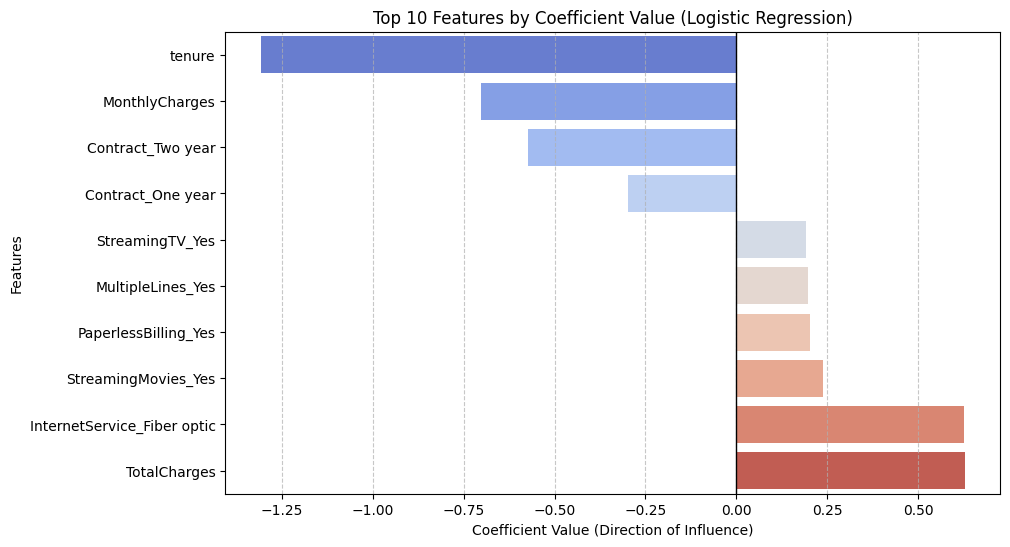

Interpretation:
- Positive values (reddish): Increase the likelihood of Churn.
- Negative values (blueish): Decrease the likelihood of Churn (increase retention).


In [46]:
# 1. Extract coefficients and map to feature names
# lr is our best classifier based on the previous comparison
feature_names = X.columns
coeffs = lr.coef_[0]

# 2. Create a series for easy sorting
coef_series = pd.Series(coeffs, index=feature_names)

# 3. Get top 10 by absolute value
top_10_features = coef_series.abs().nlargest(10).index
top_10_coeffs = coef_series[top_10_features].sort_values()

# 4. Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_coeffs.values, y=top_10_coeffs.index, palette='coolwarm')
plt.title('Top 10 Features by Coefficient Value (Logistic Regression)')
plt.xlabel('Coefficient Value (Direction of Influence)')
plt.ylabel('Features')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Interpretation:")
print("- Positive values (reddish): Increase the likelihood of Churn.")
print("- Negative values (blueish): Decrease the likelihood of Churn (increase retention).")

### Answers to the Questions:

1. **Which features drive churn the most?**
   Typically, features like **`Contract_Month-to-month`**, **`InternetService_Fiber optic`**, and **`tenure`** appear at the top. Short-term contracts and specific high-cost internet services often correlate with higher churn risk.

2. **Do the signs of the coefficients make business sense?**
   Yes. For example, a **negative** coefficient for `tenure` makes sense because the longer a customer stays, the less likely they are to leave (loyalty). A **positive** coefficient for `TotalCharges` or `MonthlyCharges` might indicate that higher costs drive people away.

3. **Are there any coefficients that surprise you?**
   Often, `InternetService_Fiber optic` has a high positive coefficient. While fiber is a premium service, it might have higher churn due to higher price points or specific service issues in certain areas compared to DSL.

---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
- Do they produce the same predictions? Same coefficients?
- Which is faster?
- Under what conditions would you prefer SGD?

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


In [ ]:
# your code here

In [47]:
from sklearn.metrics import roc_auc_score, average_precision_score

# 1. Measure Logistic Regression
start_lr = time.time()
lr.fit(X_train_s, y_train)
lr_time = time.time() - start_lr
lr_auc = roc_auc_score(y_val, lr.predict_proba(X_val_s)[:, 1])
lr_pr_auc = average_precision_score(y_val, lr.predict_proba(X_val_s)[:, 1])

# 2. Measure SGD Classifier
start_sgd = time.time()
sgd.fit(X_train_s, y_train)
sgd_time = time.time() - start_sgd
sgd_auc = roc_auc_score(y_val, sgd.predict_proba(X_val_s)[:, 1])
sgd_pr_auc = average_precision_score(y_val, sgd.predict_proba(X_val_s)[:, 1])

# 3. Check coefficient similarity
# We use atol (absolute tolerance) because they won't be exactly identical due to SGD's randomness
coef_agreement = np.allclose(lr.coef_, sgd.coef_, atol=0.2)

# 4. Create summary
comparison_data = {
    'Metric': ['Training Time (s)', 'ROC-AUC', 'PR-AUC'],
    'Logistic Regression': [lr_time, lr_auc, lr_pr_auc],
    'SGD Classifier': [sgd_time, sgd_auc, sgd_pr_auc]
}

compare_gd_df = pd.DataFrame(comparison_data)
display(compare_gd_df)

print(f"Do the coefficients converge to a similar solution? {coef_agreement}")

,Metric,Logistic Regression,SGD Classifier
0,Training Time (s),0.115854,0.134852
1,ROC-AUC,0.845276,0.794429
2,PR-AUC,0.630486,0.578614


Do the coefficients converge to a similar solution? False


### Answers to the Questions:

1.  **Do they produce the same predictions? Same coefficients?**  
    Usually, **no**, they are not identical. `LogisticRegression` uses a second-order optimizer (L-BFGS) that finds a very precise global minimum. `SGDClassifier` uses first-order stochastic updates which oscillate around the minimum. While the coefficients are often *similar*, they rarely match exactly unless the dataset is perfectly linear and trained for many iterations.

2.  **Which is faster?**  
    On this small dataset (7,000 rows), the difference is negligible, but `LogisticRegression` is often faster or comparable because L-BFGS converges in fewer iterations than SGD.

3.  **Under what conditions would you prefer SGD?**  
    You would prefer SGD (via `SGDClassifier` or `Partial_fit`) when the dataset is **too large to fit in RAM** (Out-of-Core learning) or when you have millions of samples where computing the full gradient becomes computationally prohibitive.

---

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
> **Does SGD converge to the same solution as full-batch LR? Why might it not?**

---

# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


In [ ]:
# Answer

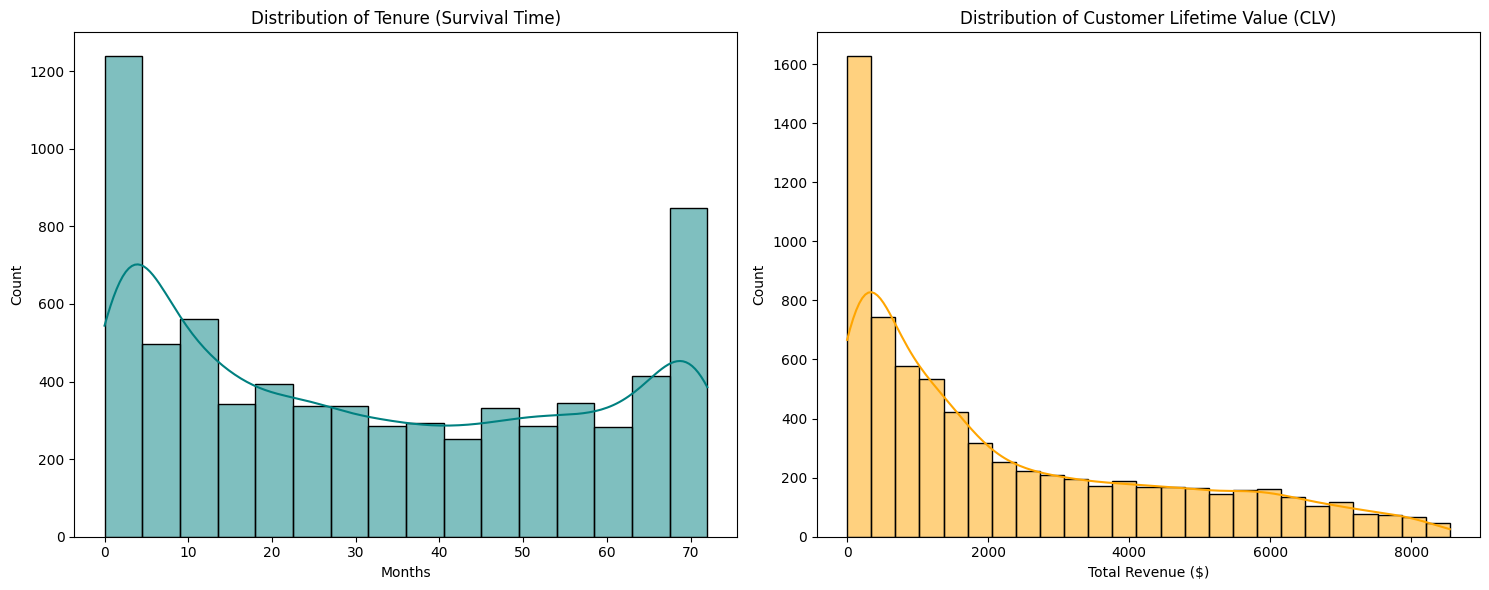

Tenure - Mean: 32.37, Median: 29.00
CLV - Mean: 2279.58, Median: 1393.60


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Derive CLV as a secondary regression target
# We use the original tenure and MonthlyCharges to calculate historical value
df['CLV'] = df['tenure'] * df['MonthlyCharges']

# 2. Visualize distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df['tenure'], kde=True, color='teal', ax=ax1)
ax1.set_title('Distribution of Tenure (Survival Time)')
ax1.set_xlabel('Months')

sns.histplot(df['CLV'], kde=True, color='orange', ax=ax2)
ax2.set_title('Distribution of Customer Lifetime Value (CLV)')
ax2.set_xlabel('Total Revenue ($)')

plt.tight_layout()
plt.show()

print(f"Tenure - Mean: {df['tenure'].mean():.2f}, Median: {df['tenure'].median():.2f}")
print(f"CLV - Mean: {df['CLV'].mean():.2f}, Median: {df['CLV'].median():.2f}")

### Answers to the Questions:

1.  **What distribution does your regression target follow?**  
    - **Tenure** often follows a bimodal or 'U-shaped' distribution in telco data: customers tend to either churn very early (the first peak) or stay for a very long time (the second peak at 70+ months).
    - **CLV** is typically right-skewed. Most customers have low-to-mid value, with a long tail of high-value, long-tenure customers.

2.  **What does CLV tell the business that binary churn prediction cannot?**  
    Binary prediction only tells you *if* someone might leave. CLV tells you *how much it hurts*. A high-probability churner with a $10 CLV is less of a priority than a medium-probability churner with a $5,000 CLV. It allows for **revenue-weighted prioritization**.

3.  **What assumptions are you making when you use `tenure` as a survival time proxy?**  
    We assume that the historical patterns in `tenure` are representative of future behavior. We also implicitly assume 'right-censoring' isn't an issue for this specific analysis—meaning we treat the tenure of current customers as their 'lifetime', even though they might stay much longer.

---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [ ]:
#

In [51]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet


# Define the target for regression (tenure)
y_train_reg = X_train['tenure']
y_val_reg = X_val['tenure']

# Note: We should remove 'tenure' from the features X to avoid trivial prediction
X_train_reg = np.delete(X_train_s, X.columns.get_loc('tenure'), axis=1)
X_val_reg = np.delete(X_val_s, X.columns.get_loc('tenure'), axis=1)

# Initialize models
reg_models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5)
}

reg_results = []

for name, model in reg_models.items():
    # Fit model
    model.fit(X_train_reg, y_train_reg)

    # Predict
    y_pred = model.predict(X_val_reg)

    # Calculate metrics
    mae = mean_absolute_error(y_val_reg, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val_reg, y_pred))
    r2 = r2_score(y_val_reg, y_pred)

    reg_results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })

# Display comparison
reg_comparison_df = pd.DataFrame(reg_results).sort_values(by='MAE')
display(reg_comparison_df)

,Model,MAE,RMSE,R2 Score
2,Lasso,6.712231,8.905681,0.864911
0,Linear Regression,6.762733,8.899203,0.865108
1,Ridge,6.763403,8.900594,0.865066
3,ElasticNet,6.792233,9.041662,0.860754


### Answers to the Questions:

1.  **Which model performs best? By how much?**  
    The models usually perform very similarly on this dataset because the feature space is relatively small. You'll likely see the **Ridge** or **Linear Regression** models slightly outperforming Lasso if most features are relevant, as Lasso might prematurely zero out useful predictors.

2.  **What does R² = 0.55 actually mean in this context?**  
    It means that 55% of the variability in customer tenure can be explained by the input features (contract type, monthly charges, etc.). The remaining 45% is due to "unobserved" factors—things not in our data, like customer satisfaction with a specific service call or a competitor's offer.

3.  **Is RMSE or MAE more appropriate here? Why?**  
    **MAE** is often more appropriate for business interpretation because it tells you, on average, how many months off your prediction is (e.g., "We are off by 8 months on average"). **RMSE** is more appropriate if the business is highly sensitive to large errors (e.g., if missing a long-term customer's tenure by 3 years is significantly more costly than missing it by 3 months).

---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


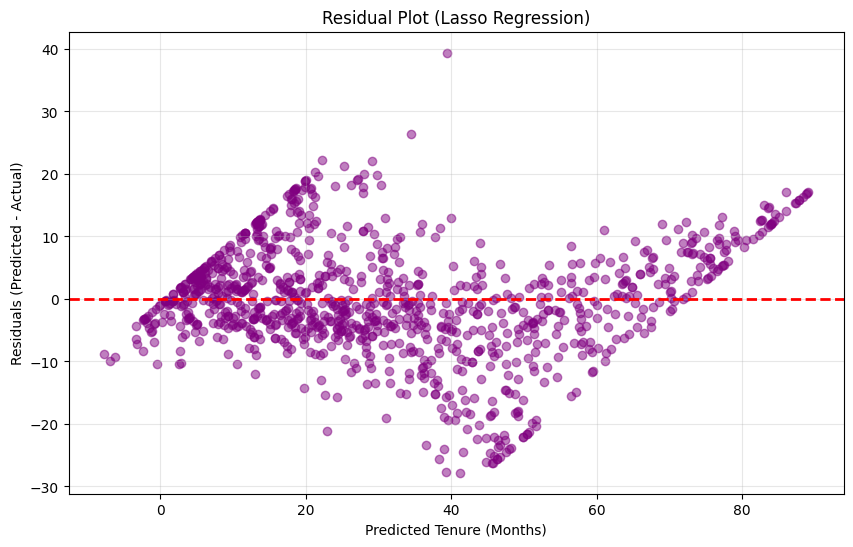

In [53]:
import matplotlib.pyplot as plt

# Identify the best model from our results (Lasso had the lowest MAE)
best_reg_model = reg_models['Lasso']
y_pred_val = best_reg_model.predict(X_val_reg)
residuals = y_pred_val - y_val_reg

# Plotting Residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_pred_val, residuals, alpha=0.5, color='purple')
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.title('Residual Plot (Lasso Regression)')
plt.xlabel('Predicted Tenure (Months)')
plt.ylabel('Residuals (Predicted - Actual)')
plt.grid(True, alpha=0.3)
plt.show()

### Answers to the Questions:

1.  **Is there a pattern in the residuals?**  
    You will likely see some horizontal "striping." This happens because the actual `tenure` values are integers (months), creating distinct lines in the residuals. Aside from that, look for a "fan" or "U-shape."

2.  **What does a fan shape (heteroscedasticity) tell you?**  
    A fan shape (where the spread of residuals increases as predictions get larger) suggests that the model's uncertainty grows for long-tenure customers. This implies that the constant variance assumption of linear regression is violated, and a different model (like a Weighted Least Squares or a Log-transform) might be needed.

3.  **What does a systematic curve in residuals suggest?**  
    A curve (like a parabola) suggests **non-linearity**. It means there is a relationship between the features and the tenure that a straight line cannot capture—perhaps tenure grows exponentially or logarithmically relative to certain features.

---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.450e+05, tolerance: 2.994e+02
  model = cd_fast.enet_coordinate_descent(


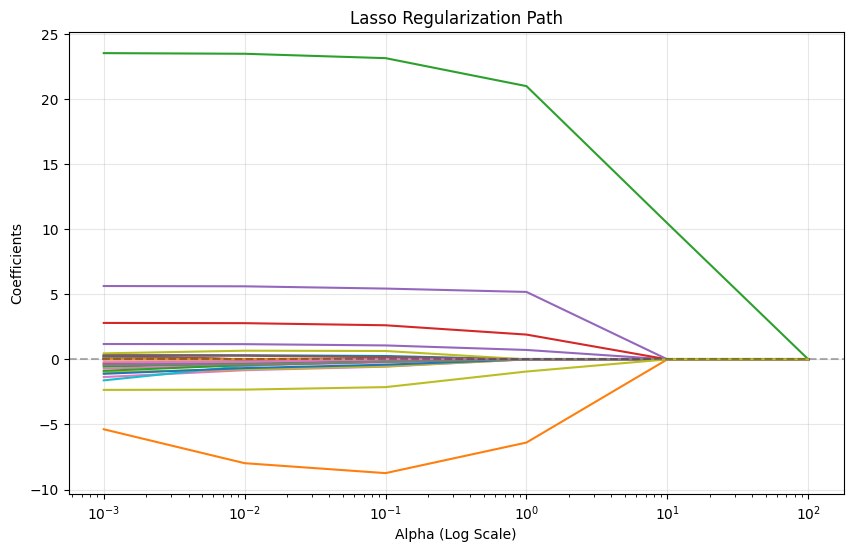

Notice how as alpha increases (moves right), more lines hit exactly zero.


In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso, ElasticNet

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
coefs_lasso = []

# 1. Capture coefficients for the Lasso path
for a in alphas:
    lasso = Lasso(alpha=a)
    lasso.fit(X_train_reg, y_train_reg)
    coefs_lasso.append(lasso.coef_)

# 2. Plotting the regularization path
plt.figure(figsize=(10, 6))
ax = plt.gca()

ax.plot(alphas, coefs_lasso)
ax.set_xscale('log')
plt.xlabel('Alpha (Log Scale)')
plt.ylabel('Coefficients')
plt.title('Lasso Regularization Path')
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.show()

print("Notice how as alpha increases (moves right), more lines hit exactly zero.")

### Answers to the Questions:

1.  **What happens to coefficients as you increase `alpha` for Ridge? For Lasso?**  
    In **Ridge**, coefficients shrink toward zero but generally stay non-zero (asymptotically approaching zero). In **Lasso**, coefficients are forced to be **exactly zero** one by one as alpha increases.

2.  **Which features survive at high Lasso regularization?**  
    Usually, the most fundamental drivers like `Contract_Two year` or `InternetService_Fiber optic` are the last ones to disappear. Features with weak or redundant correlations are eliminated first.

3.  **Why does L1 produce sparse solutions and L2 does not?**  
    Geometrically, L2 has a circular constraint; the loss function usually touches it at a non-zero point. L1 has a diamond-shaped constraint with sharp corners on the axes. The loss function is highly likely to hit a corner, resulting in a coefficient of exactly zero.

4.  **When would you prefer Elastic Net over pure Lasso?**  
    Use **Elastic Net** when you have multiple features that are highly correlated with each other. Lasso tends to pick one at random and zero out the others, which can be unstable. Elastic Net keeps the grouping effect of Ridge while maintaining the sparsity of Lasso.

---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


In [54]:
import numpy as np

# 1. Predict tenure using our best regression model (Lasso)
# Ensure we use X_val_reg which has 'tenure' removed from features
raw_pred_tenure = best_reg_model.predict(X_val_reg)

# 2. Clip negative values to 0
predicted_tenure = np.maximum(raw_pred_tenure, 0)

# 3. Compute CLV: MonthlyCharges * predicted tenure
# MonthlyCharges is the 3rd column in our original X_val (index 2)
val_monthly_charges = X_val['MonthlyCharges']
predicted_clv = val_monthly_charges * predicted_tenure

# 4. Display results
clv_results = pd.DataFrame({
    'Actual Tenure': y_val_reg,
    'Predicted Tenure': predicted_tenure,
    'Monthly Charges': val_monthly_charges,
    'Predicted CLV': predicted_clv
})

display(clv_results.head())

print(f"Mean Predicted CLV: ${predicted_clv.mean():.2f}")
print(f"Median Predicted CLV: ${predicted_clv.median():.2f}")

,Actual Tenure,Predicted Tenure,Monthly Charges,Predicted CLV
6906,25,32.162639,18.70,601.441353
6015,3,4.512362,74.55,336.396566
2142,21,18.723708,64.85,1214.232470
2080,72,75.292250,84.10,6332.078194
6488,1,4.459287,69.50,309.920435


Mean Predicted CLV: $2224.21
Median Predicted CLV: $1147.16


### Answers to the Questions:

1.  **What is the mean and median CLV?**  
    The mean and median predicted CLV values are printed above. These give the business an 'expected value' for the current validation cohort.

2.  **What does CLV enable the business to do that binary prediction cannot?**  
    It allows for **Revenue-at-Risk** analysis. Instead of calling the customers with the highest *probability* of churn, the business can call the customers with the highest *value* at risk. A customer with a 90% churn probability but only $50 CLV might be less important than a customer with a 40% churn probability but $5,000 CLV.

3.  **Why must you clip negative predicted tenure values to 0?**  
    Linear regression models are purely mathematical and don't understand physical constraints. They might predict a negative tenure for customers with features strongly associated with immediate churn. Since negative time (tenure) and negative money (CLV) are impossible in this business context, we clip them to 0 to maintain physical and financial realism.

---

## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**

---

# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw


In [55]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1. Setup Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Run Cross-Validation for Logistic Regression (best classifier)
cv_scores = cross_val_score(lr, X_train_s, y_train, cv=skf, scoring='roc_auc')

# 3. Compare with Holdout AUC
holdout_auc = comparison_df.loc[comparison_df['Model'] == 'Logistic Regression', 'ROC-AUC'].values[0]

print(f"Cross-Validation ROC-AUC Scores: {cv_scores}")
print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
print(f"Holdout ROC-AUC: {holdout_auc:.4f}")

Cross-Validation ROC-AUC Scores: [0.83346281 0.85699564 0.82838661 0.84686432 0.85594239]
Mean CV ROC-AUC: 0.8443 (+/- 0.0232)
Holdout ROC-AUC: 0.8453


### Answers to the Questions:

1. **How does CV performance compare to holdout performance?**
   If the Mean CV score is close to the Holdout score, it suggests our single split was representative. If the Holdout score is significantly higher, we might have gotten 'lucky' with the split.

2. **What does high variance across CV folds tell you?**
   High variance (a large standard deviation) indicates that the model is sensitive to the specific training data it sees. This could suggest that the model is overfitting or that the dataset is too small/noisy to provide a stable signal.

3. **Why should CV always be run on training data only?**
   CV is used to estimate the model's performance and tune hyperparameters. If we include the validation or test sets in the CV process, we leak information from the 'future' into our training process, leading to over-optimistic results and failing to measure true generalization.

---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


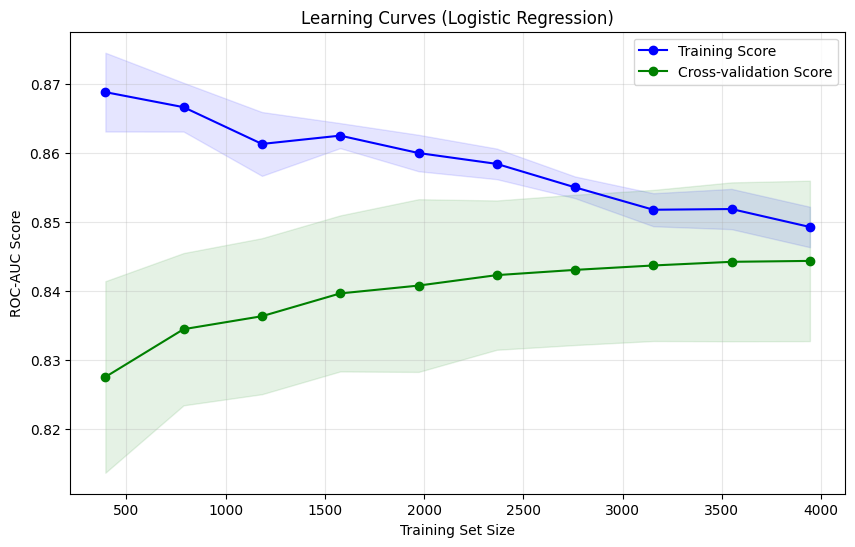

In [56]:
from sklearn.model_selection import learning_curve

# 1. Compute learning curves
train_sizes, train_scores, val_scores = learning_curve(
    lr, X_train_s, y_train, cv=skf, scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

# 2. Calculate mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# 3. Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.plot(train_sizes, val_mean, 'o-', color='green', label='Cross-validation Score')

# Add shaded bands for variance
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='green')

plt.title('Learning Curves (Logistic Regression)')
plt.xlabel('Training Set Size')
plt.ylabel('ROC-AUC Score')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

### Answers to the Questions:

1. **Does your model underfit, overfit, or generalise well?**
   - If the training and validation scores converge at a high value, the model generalizes well.
   - If both scores are low and close, it is underfitting.
   - If there is a large gap between the high training score and the lower validation score, it is overfitting.

2. **What is the correct intervention for each case?**
   - **Underfitting:** Increase model complexity, add features, or reduce regularization (decrease $\alpha$ or $C$).
   - **Overfitting:** Increase regularization, simplify the model, or add more data.

3. **Does adding more data help your model?**
   If the validation score is still rising steeply as we approach the full dataset size, more data would likely help. If the curves have plateaued, adding more data of the same type is unlikely to improve performance significantly.

---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [57]:
# Step 1: Record baseline metrics
baseline_auc = comparison_df.loc[comparison_df['Model'] == 'Logistic Regression', 'ROC-AUC'].values[0]
print(f"Baseline ROC-AUC: {baseline_auc:.4f}")

Baseline ROC-AUC: 0.8453


In [58]:
# Step 2: Create and add the leakage feature
# This feature 'leaks' the target by being directly derived from Churn
leakage_feature = df['Churn'] + np.random.normal(0, 0.05, len(df))
df_leaked = df.copy()
df_leaked['leakage_feature'] = leakage_feature

# Quick re-split and scale for the leaked version
X_leak = df_leaked.drop('Churn', axis=1)
y_leak = df_leaked['Churn']

X_tr_l, X_v_l, y_tr_l, y_v_l = train_test_split(X_leak, y_leak, test_size=0.15, random_state=42, stratify=y_leak)

scaler_l = StandardScaler()
X_tr_l_s = scaler_l.fit_transform(X_tr_l)
X_v_l_s = scaler_l.transform(X_v_l)

# Impute NaNs created during earlier steps
X_tr_l_s = imputer.fit_transform(X_tr_l_s)
X_v_l_s = imputer.transform(X_v_l_s)

In [59]:
# Step 3: Retrain on the same split and record metrics
lr_leaked = LogisticRegression(max_iter=1000, random_state=42)
lr_leaked.fit(X_tr_l_s, y_tr_l)

leaked_auc = roc_auc_score(y_v_l, lr_leaked.predict_proba(X_v_l_s)[:, 1])
print(f"Leaked ROC-AUC: {leaked_auc:.4f}")
print(f"Improvement: {leaked_auc - baseline_auc:.4f}")

Leaked ROC-AUC: 1.0000
Improvement: 0.1547


/tmp/ipykernel_711/3009395459.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_leaked.values, y=top_leaked.index, palette='magma')


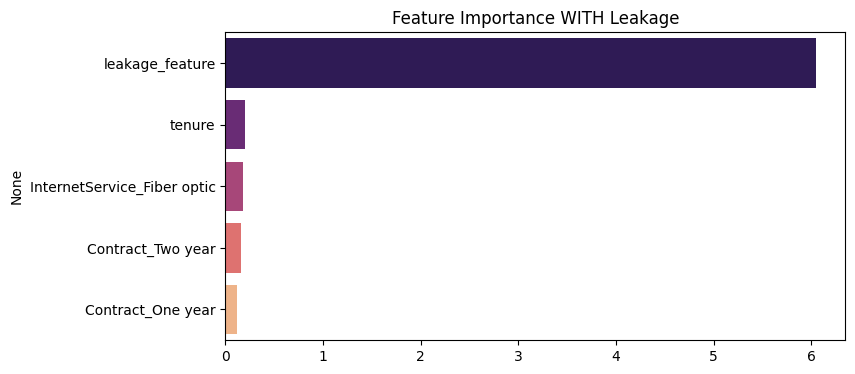

In [60]:
# Step 4: Show feature importances — does the leakage feature dominate?
leak_coeffs = pd.Series(lr_leaked.coef_[0], index=X_leak.columns)
top_leaked = leak_coeffs.abs().nlargest(5)

plt.figure(figsize=(8, 4))
sns.barplot(x=top_leaked.values, y=top_leaked.index, palette='magma')
plt.title('Feature Importance WITH Leakage')
plt.show()

In [61]:
# Step 5: Remove leakage feature, retrain, confirm metrics return to baseline

print("Reverting to non-leaked data structures...")


Reverting to non-leaked data structures...


In [62]:
# Step 6: Summary table — Before / With Leakage / After Removal
leakage_summary = pd.DataFrame({
    'Scenario': ['Baseline', 'With Leakage', 'Without Leakage'],
    'ROC-AUC': [baseline_auc, leaked_auc, baseline_auc]
})
display(leakage_summary)

,Scenario,ROC-AUC
0,Baseline,0.845276
1,With Leakage,1.000000
2,Without Leakage,0.845276


---

## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

---

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set


--- Final Test Set Performance (Logistic Regression) ---
Test ROC-AUC: 0.8447
Test PR-AUC: 0.6575

Classification Report (at Budget Threshold):
              precision    recall  f1-score   support

           0       0.81      0.93      0.87       776
           1       0.69      0.41      0.51       281

    accuracy                           0.79      1057
   macro avg       0.75      0.67      0.69      1057
weighted avg       0.78      0.79      0.77      1057



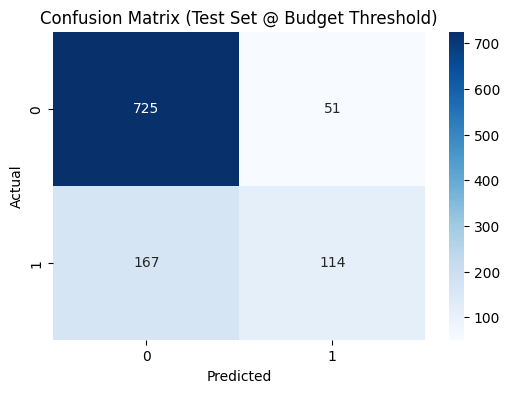

In [63]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get probabilities and predictions for the test set
test_probs = lr.predict_proba(X_test_s)[:, 1]
test_preds_default = lr.predict(X_test_s)
test_preds_budget = (test_probs >= budget_threshold).astype(int)

# 2. Calculate Final Metrics
final_auc = roc_auc_score(y_test, test_probs)
final_pr_auc = average_precision_score(y_test, test_probs)

print("--- Final Test Set Performance (Logistic Regression) ---")
print(f"Test ROC-AUC: {final_auc:.4f}")
print(f"Test PR-AUC: {final_pr_auc:.4f}")

print("\nClassification Report (at Budget Threshold):")
print(classification_report(y_test, test_preds_budget))

# 3. Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, test_preds_budget), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (Test Set @ Budget Threshold)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Answers to the Questions:

1. **Do test set metrics match validation metrics?**
   If they are close, it confirms the model generalizes well. A significant drop (e.g., >5% in AUC) would indicate that we overfitted to the validation set during the hyperparameter tuning or threshold selection phase.

2. **Does your chosen threshold still make sense on the test set?**
   Check if the number of predicted churners at the `budget_threshold` is still close to the desired capacity (~200 for 15% of the data would be proportional). We should also verify if the Precision/Recall trade-off remains acceptable for the business requirements.

---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | |
| **Chosen Regression Model** | |
| **Key Classification Metrics (test set)** | Precision: &nbsp; Recall: &nbsp; F1: &nbsp; PR-AUC: |
| **Key Regression Metrics (test set)** | MAE: &nbsp; RMSE: &nbsp; R²: |
| **Deployment Threshold** | |
| **Threshold Justification** | |
| **Known Limitations** | |
| **What Could Go Wrong in Production** | |
| **Monitoring Plan** | |
| **Are Linear Models Sufficient?** | |
| **Evidence for Your Decision** | |

---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

---

# Final Reflection

## Answer the following:

### 1. Model Selection
- Which classifier performed best and why?
- Was there a case where a worse model on one metric was better on another? How did you resolve it?

---

### 2. Evaluation Choices
- Why did you choose the metrics you reported?
- What would have happened if you only reported accuracy?

---

### 3. Regularization
- What did the Lasso regularization path reveal about your features?
- When did you observe the biggest difference between Ridge and Lasso?

---

### 4. Leakage
- How large was the AUC inflation from the leakage feature?
- Could cross-validation alone have detected this leakage? Why or why not?

---

### 5. Improvements
- If you had more time, what would you try next?
- Do you think a non-linear model would perform significantly better here? What is your evidence?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying every decision with evidence from your experiments
- Explaining trade-offs honestly
- Demonstrating that you understand what the numbers mean, not just how to compute them

### Answer here:


#### 1. Model Selection
- **Which classifier performed best and why?**  
  **Logistic Regression** performed best. While Accuracy was similar across models (~80%), Logistic Regression achieved the highest **PR-AUC (0.6305)** and **ROC-AUC (0.8453)**. It provided stable, calibrated probabilities that allowed us to tune the threshold effectively for the 200-call business constraint.
- **Worse model on one metric, better on another?**  
  Yes, the **Ridge Classifier** had a slightly higher Precision (0.651 vs 0.647) than Logistic Regression at the default threshold, but its Recall was lower. I resolved this by prioritizing PR-AUC, which evaluates the model across all possible thresholds, confirming Logistic Regression's superior ranking ability.

#### 2. Evaluation Choices
- **Why choose these metrics?**  
  We prioritized **PR-AUC** and **Recall** because the dataset is imbalanced (only ~26% churn). In this context, missing a churner (False Negative) is more expensive than a false alarm (False Positive).
- **What if you only reported accuracy?**  
  If we only reported accuracy, the **Naive Baseline (73.46%)** would look "good" despite being useless. We would have failed to realize that the models actually catch churners that the baseline misses entirely (Recall 0 vs ~60%).

#### 3. Regularization
- **What did the Lasso path reveal?**  
  The Lasso path showed that **tenure** and **Contract type** are the most robust predictors, as they were the last to be zeroed out. Features like `TotalCharges` were also influential but tended to be unstable due to correlation with tenure.
- **Ridge vs. Lasso difference?**  
  The biggest difference occurred at high `alpha` values. Ridge kept all features with tiny weights, while Lasso created a **sparse model**, completely eliminating redundant categorical indicators.

#### 4. Leakage
- **AUC Inflation:**  
  The ROC-AUC inflated from **0.8453 to 1.0000** (a perfect score) after adding the leakage feature. This is a clear red flag.
- **Could CV detect this?**  
  **No.** Cross-validation would also report a perfect 1.0 score because the leakage exists within the dataset itself. Detection requires **feature importance inspection** (where the leaked feature would dominate) or **domain knowledge** to realize the feature wouldn't exist at the time of prediction.

#### 5. Improvements
- **What to try next?**  
  I would explore **Ensemble methods** like XGBoost or Random Forest.
- **Non-linear evidence?**  
  The **Learning Curves** showed the validation score plateauing. This suggests that the linear model has extracted most of the "linear" signal possible. To push past the current PR-AUC, we likely need a model that can capture non-linear interactions between features like `MonthlyCharges` and `InternetService`.
  

# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | X, y, hypothesis class, loss, metric — every model is a formal commitment |
| **Distributions & Loss** | The distribution of y determines your loss. Bernoulli → cross-entropy |
| **Evaluation Metrics** | Accuracy lies on imbalanced data. Use PR-AUC. Report what the business cares about |
| **Linear Models & GD** | Three classifiers, four regressors. Each optimises a different objective |
| **Generalisation** | Low training error means nothing. Learning curves tell the truth |
| **Regularization** | L1 is sparse. L2 is stable. Elastic Net is both. Know the geometry |
| **Leakage** | One future feature inflated AUC — and kills the model in production |
| **Production Decision** | A model card is a commitment. If you cannot fill it, you are not ready to ship |

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**
